# E13 Polar Orthogonalization Vs Normalization Ablation

### Problem

This notebook separates polar/spectral orthogonalization from simpler norm-normalization effects. It tests whether Muon-family gains can be explained by update normalization alone, or whether exact/approximate polar directions add a distinct benefit.

## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [2]:
NOTEBOOK_ID = "E13 polar vs normalization"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Muon-NS-1", "Muon-Truncated", "Muon-RandSVD", "NormalizedSGD", "SpectralNormSGD", "LayerwiseNormalizedSGD", "Adam", "SGD"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 800

BASE_SPEC = dict(d=60, rank=5, lr=0.01, iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
                 diagnostic_every=1 if SMOKE_TEST else 20, early_stop=True, early_stop_min_steps=100,
                 early_stop_patience=20, early_stop_min_delta=1e-8, device_type=DEVICE.type, dtype_name=DTYPE_NAME)
SETTINGS = [
    dict(setting="MS-easy", problem="MatrixSensing", spectrum="hard-cutoff", kappa=1.0, m_multiplier=8, noise=0.0, dist="normal", init_scale=1e-2),
    dict(setting="MS-hard", problem="MatrixSensing", spectrum="exponential-decay", kappa=100.0, m_multiplier=4, noise=0.0, dist="normal", init_scale=1e-2),
    dict(setting="MF-standard", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-2, right_scale=1e-2),
    dict(setting="MF-imbalanced", problem="MatrixFactorization", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([{**BASE_SPEC, **setting, "algo": algo, "seed": seed}
                     for setting in SETTINGS for algo in ALGOS for seed in SEEDS])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
runs=200, max_total_steps=160000


,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,kappa,m_multiplier,noise,dist,init_scale,algo,seed,factor_rank,left_scale,right_scale
0,0,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,0,NaN,NaN,NaN
1,1,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,1,NaN,NaN,NaN
2,2,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,2,NaN,NaN,NaN
3,3,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,3,NaN,NaN,NaN
4,4,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,8.0,0.0,normal,0.01,Muon,4,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,0,5.0,0.0001,1.0
196,196,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,1,5.0,0.0001,1.0
197,197,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,2,5.0,0.0001,1.0
198,198,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.0,NaN,NaN,NaN,NaN,SGD,3,5.0,0.0001,1.0


### Pseudocode

```text
for each selected MS/MF setting and optimizer:
    build the problem using repo problem constructors
    train while recording actual parameter updates
    compare recovery error, time per step, update effective rank, and descent alignment
```

### Worker Definition

In [ ]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    params = []
    if run["problem"] == "MatrixSensing":
        problem = problems.MatrixSensing.make_matrix_sensing_problem(
            run["d"], run["rank"], noise=run["noise"], dist=run["dist"], spectrum=run["spectrum"], kappa=run["kappa"],
            seed=run["seed"], device=device, dtype=dtype, m_multiplier=run["m_multiplier"])
        x = (run["init_scale"] * randn((run["d"], run["d"]), run["seed"] + 10, device, dtype)).requires_grad_(True)
        params = [x]
        def current_loss(): return problem.loss(x)
        def estimate(): return x
        opt_rank = run["rank"]
    else:
        problem = problems.MatrixFactorization.make_matrix_factorization_problem(
            run["d"], run["rank"], spectrum=run["spectrum"], kappa=run["kappa"], seed=run["seed"], device=device, dtype=dtype,
            factor_rank=run["factor_rank"], num_factors=int(run.get("num_factors", 10)))
        factor_inits = problems.MatrixFactorization.initialize_factor_chain(
            int(run["d"]), int(run["factor_rank"]), seed=int(run["seed"]) + 10, device=device, dtype=dtype,
            num_factors=int(run.get("num_factors", 10)),
            left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
        )
        factors = [factor.requires_grad_(True) for factor in factor_inits]
        params = factors
        def current_loss(): return problem.loss(*factors)
        def estimate(): return problem.estimate(*factors)
        opt_rank = run["rank"]
    opt = make_optimizer(run["algo"], params, run["lr"], rank=opt_rank)
    initial_loss = float(current_loss().detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            rows.append({**run, "step": step, "initial_loss": initial_loss, "loss": float(current_loss().detach().cpu()),
                         "best_loss": best_loss, "recovery_error": util.diagnostics.relative_matrix_error(estimate(), problem.target),
                         "top_sv_error": util.diagnostics.top_singular_value_error(estimate(), problem.target, k=run["rank"]),
                         "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason})
        if step == run["iters"]:
            break
        loss = current_loss()
        loss.backward()
        params_before = [p.detach().clone() for p in params]
        grads = [p.grad.detach().clone() for p in params]
        opt.step()
        params_after = [p.detach().clone() for p in params]
        for p in params:
            p.grad = None
        if do_diag and rows:
            rows[-1].update(relative_update_diagnostics(params_before, params_after, grads))
        current = float(current_loss().detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
                            algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID)
IPython.display.display(runs)


E13 polar vs normalization:   0%|          | 0/200 [00:00<?, ?run/s]

E13 polar vs normalization:   0%|          | 1/200 [00:06<21:36,  6.51s/run]

E13 polar vs normalization:   2%|▏         | 4/200 [00:07<05:12,  1.59s/run]

E13 polar vs normalization:   3%|▎         | 6/200 [00:10<04:28,  1.39s/run]

E13 polar vs normalization:   4%|▍         | 9/200 [00:11<03:10,  1.00run/s]

...

E13 polar vs normalization:  86%|████████▌ | 171/200 [01:04<00:02, 12.11run/s]

E13 polar vs normalization:  92%|█████████▎| 185/200 [01:06<00:01, 10.28run/s]

E13 polar vs normalization: 100%|██████████| 200/200 [01:07<00:00, 11.26run/s]

E13 polar vs normalization: 100%|██████████| 200/200 [01:07<00:00,  2.98run/s]

,run_id,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,...,descent_alignment,relative_step_size,update_fro_norm,update_op_norm,update_effective_rank,update_stable_rank,grad_fro_norm,grad_op_norm,grad_effective_rank,grad_stable_rank
0,0,60,5,0.01,800,20,True,100,20,1.000000e-08,...,0.794383,1.176039e-01,0.069870,0.011752,58.141815,35.348197,3.679090,1.231798,43.655186,8.920760
1,0,60,5,0.01,800,20,True,100,20,1.000000e-08,...,0.586418,5.357273e-02,0.066991,0.011997,58.208999,31.182719,1.092687,0.391462,42.262788,7.791336
2,0,60,5,0.01,800,20,True,100,20,1.000000e-08,...,0.392543,3.819884e-02,0.070678,0.011638,58.998479,36.880333,0.440847,0.114173,47.253353,14.909122
3,0,60,5,0.01,800,20,True,100,20,1.000000e-08,...,0.264062,3.262561e-02,0.067886,0.011970,58.866200,32.164844,0.223398,0.056449,47.783545,15.662133
4,0,60,5,0.01,800,20,True,100,20,1.000000e-08,...,0.323574,3.180667e-02,0.067432,0.011350,58.913546,35.295415,0.143673,0.035801,47.609976,16.105031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2815,199,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.000000,6.787021e-07,0.000012,0.000005,3.940544,0.806272,0.001219,0.000481,3.940544,1.626353
2816,199,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.000000,6.761723e-07,0.000012,0.000005,3.940443,0.806345,0.001214,0.000479,3.940443,1.626688
2817,199,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.000000,6.736529e-07,0.000012,0.000005,3.940370,0.806420,0.001210,0.000478,3.940370,1.627026
2818,199,60,5,0.01,800,20,True,100,20,1.000000e-08,...,1.000000,6.711437e-07,0.000012,0.000005,3.940323,0.806496,0.001205,0.000476,3.940323,1.627367


### Individual Loss Curves

Each figure below keeps every `run_id` as a separate line. Color encodes optimizer; panel labels encode the experiment setting.

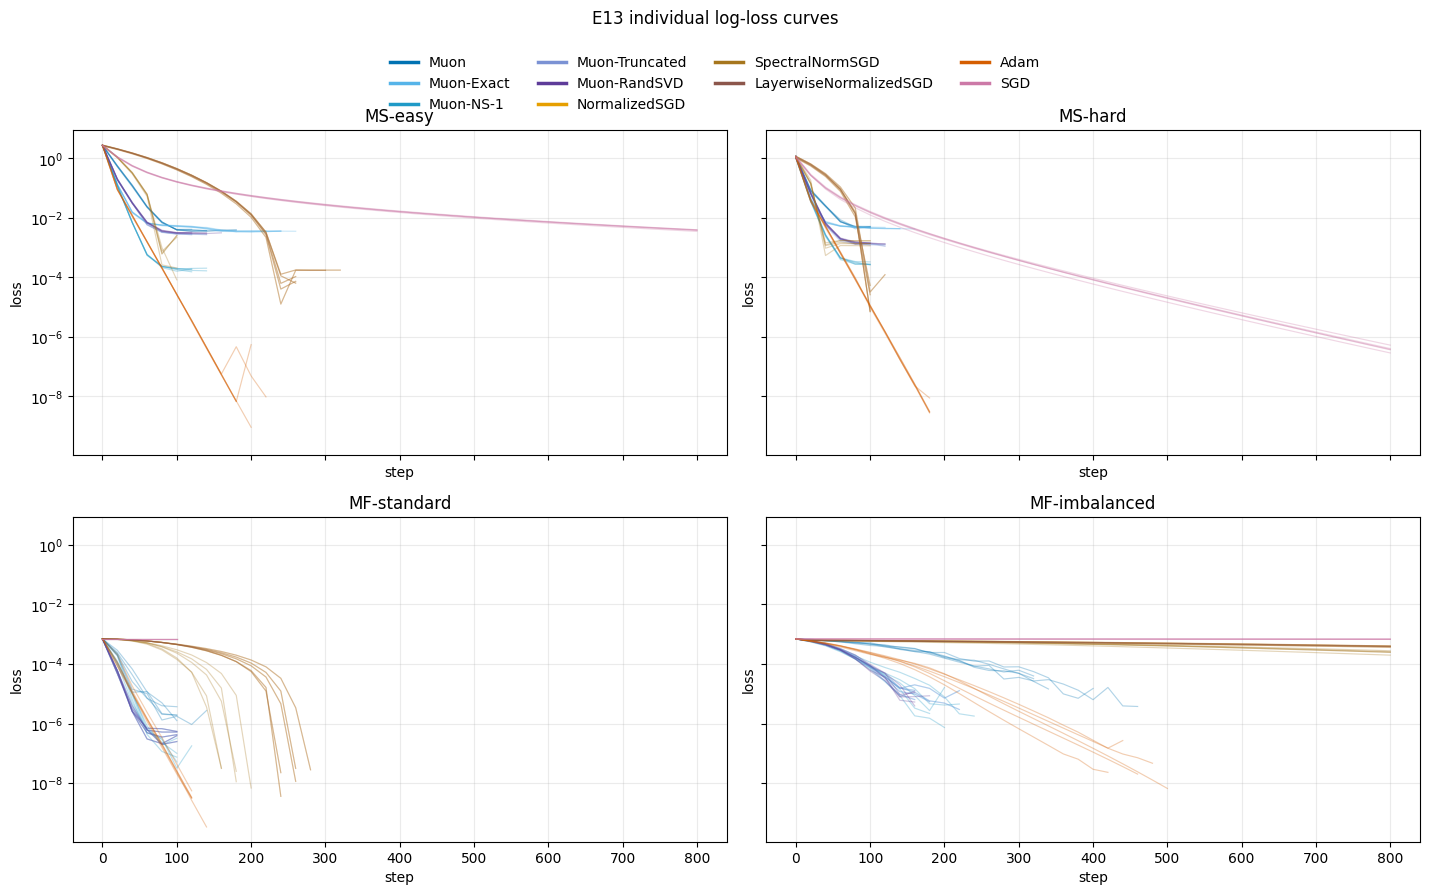

In [5]:
import plotting
from matplotlib.lines import Line2D


def plot_individual_loss_curves(frame, panel_column, *, panel_order=None, title_prefix="Individual loss curves"):
    plot_frame = frame[np.isfinite(frame["loss"])].copy()
    if plot_frame.empty:
        print("No finite loss values to plot.")
        return None, None
    plot_frame["loss_plot"] = plot_frame["loss"].clip(lower=1e-300)
    panels = list(panel_order) if panel_order is not None else sorted(plot_frame[panel_column].dropna().unique())
    ncols = min(2, max(1, len(panels)))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.2 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, panel in zip(axes_flat, panels):
        sub = plot_frame[plot_frame[panel_column] == panel].sort_values(["run_id", "step"])
        run_count = max(1, sub["run_id"].nunique())
        alpha = max(0.04, min(0.30, 18.0 / run_count))
        for _, group in sub.groupby("run_id", observed=True, sort=False):
            algo = str(group["algo"].iloc[0])
            ax.plot(
                group["step"],
                group["loss_plot"],
                color=plotting.algorithm_color(algo),
                linewidth=0.85,
                alpha=alpha,
            )
        ax.set_title(str(panel))
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    algos = [algo for algo in ALGOS if algo in set(plot_frame["algo"].astype(str))]
    handles = [Line2D([0], [0], color=plotting.algorithm_color(algo), linewidth=2.5, label=algo) for algo in algos]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(title_prefix, y=1.06 if handles else 1.02)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_individual_loss_curves(runs, "setting", panel_order=[setting["setting"] for setting in SETTINGS], title_prefix="E13 individual log-loss curves")
plt.show()


### Result Tables

In [6]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"), median_top_sv_error=("top_sv_error", "median"),
    median_update_effective_rank=("update_effective_rank", "median"), median_alignment=("descent_alignment", "median"),
    median_step_size=("relative_step_size", "median"), median_time=("elapsed_s", "median"))
IPython.display.display(summary.sort_values(["setting", "median_recovery"]))


,setting,algo,median_recovery,median_top_sv_error,median_update_effective_rank,median_alignment,median_step_size,median_time
0,MF-imbalanced,Adam,0.005740,0.000717,3.212159,0.834445,1.810101e-04,0.265842
4,MF-imbalanced,Muon-NS-1,0.055976,0.031945,3.299977,0.065613,1.405425e-03,0.132123
3,MF-imbalanced,Muon-Exact,0.095800,0.048159,4.200690,0.153823,2.887865e-03,0.134307
6,MF-imbalanced,Muon-Truncated,0.095800,0.048159,4.200690,0.153823,2.887865e-03,0.107190
5,MF-imbalanced,Muon-RandSVD,0.111048,0.048752,3.936560,0.078319,3.663700e-03,0.135025
2,MF-imbalanced,Muon,0.146978,0.068403,4.917088,0.272785,8.860961e-03,0.403688
9,MF-imbalanced,SpectralNormSGD,0.595739,0.368457,NaN,NaN,NaN,0.470732
1,MF-imbalanced,LayerwiseNormalizedSGD,0.749762,0.485384,NaN,NaN,NaN,0.379827
7,MF-imbalanced,NormalizedSGD,0.749762,0.485384,NaN,NaN,NaN,0.579925
8,MF-imbalanced,SGD,0.989048,0.967259,NaN,NaN,NaN,0.269581


### Accuracy-Cost Scatter

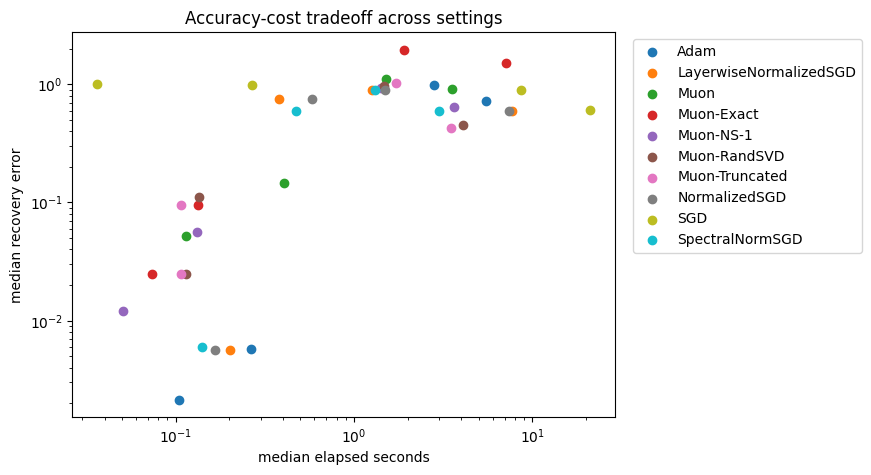

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for algo, group in summary.groupby("algo", observed=True):
    ax.scatter(group["median_time"], group["median_recovery"], label=algo)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("median elapsed seconds")
ax.set_ylabel("median recovery error")
ax.set_title("Accuracy-cost tradeoff across settings")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


### Normalization Baselines Vs Polar Variants

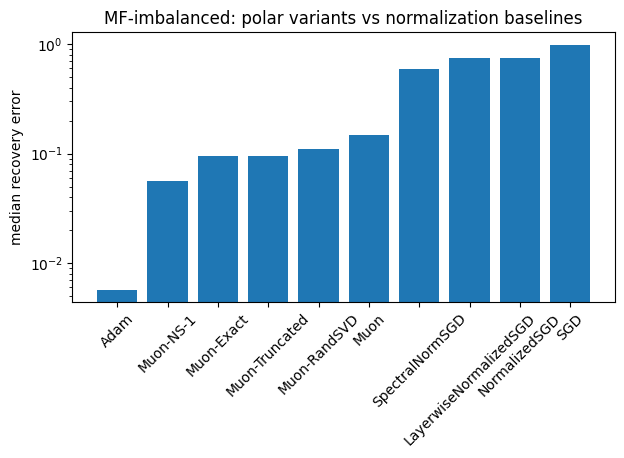

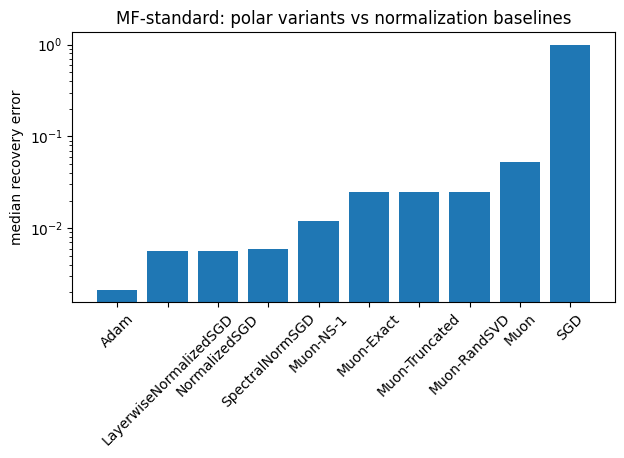

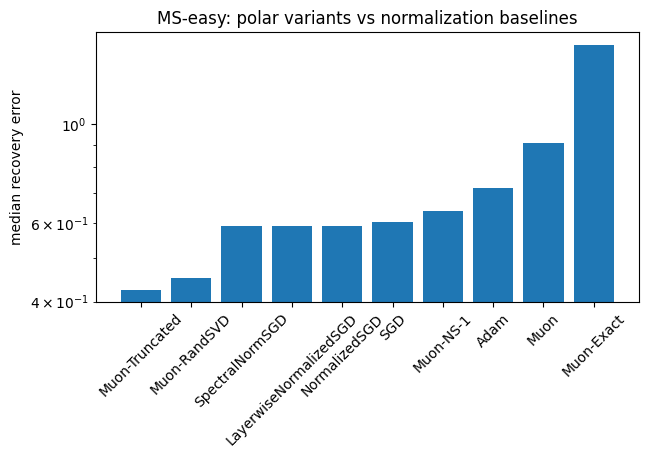

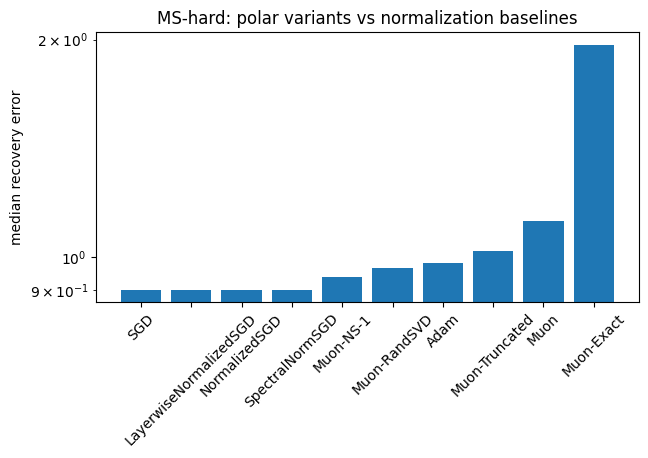

In [8]:
for setting in sorted(summary["setting"].unique()):
    sub = summary[summary["setting"] == setting].sort_values("median_recovery")
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(sub["algo"], sub["median_recovery"])
    ax.set_yscale("log")
    ax.set_title(f"{setting}: polar variants vs normalization baselines")
    ax.set_ylabel("median recovery error")
    ax.tick_params(axis="x", rotation=45)
    plt.show()


### Reading The Result

If normalization baselines match Muon-family methods, the effect is likely explained by norm geometry. If Muon-Exact or Muon-NS-1 beats all normalization baselines in a setting, that is evidence for a distinct polar/spectral mechanism.